***Data Importing and Dataframe Inspection***

In [10]:
import pandas as pd

survey_data = pd.read_csv('BookstoreSurvey.csv', header=[0,1])
print(survey_data.head())

                                           StartDate  \
                                          Start Date   
0  {"ImportId":"startDate","timeZone":"America/Ne...   
1                                2026-04-06 16:01:04   
2                                2026-04-06 16:10:06   
3                                2026-04-06 18:15:08   
4                                2026-04-06 18:16:00   

                                             EndDate                 Status  \
                                            End Date          Response Type   
0  {"ImportId":"endDate","timeZone":"America/New_...  {"ImportId":"status"}   
1                                2026-04-06 16:03:18             IP Address   
2                                2026-04-06 16:13:47             IP Address   
3                                2026-04-06 18:17:38             IP Address   
4                                2026-04-06 18:17:46             IP Address   

                  IPAddress                 Progress 

***Basic Cleaning and Droping of Uneeded Rows/Columns***

In [11]:
survey_data = survey_data.drop(survey_data.index[0]).reset_index(drop=True)

dropped_columns = ['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName',
                    'RecipientEmail', 'ExternalReference', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage']

survey_data = survey_data.drop(columns=dropped_columns)
survey_data = survey_data.drop(survey_data.index[[37,48]]).reset_index(drop=True)
print(survey_data.head(5))



                                   Q1  \
  What is your affiliation with CWRU?   
0               Undergraduate student   
1               Undergraduate student   
2               Undergraduate student   
3               Undergraduate student   
4               Undergraduate student   

                                                            Q4  \
  Have you ever browsed the CWRU bookstore (in-person/online)?   
0                                                yes             
1                                                yes             
2                                                yes             
3                                                yes             
4                                                yes             

                                                                   Q6  \
  Have you ever purchased from the CWRU bookstore (in-person/online)?   
0                                                yes                    
1                             

/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_49651/4185514605.py:6: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  survey_data = survey_data.drop(columns=dropped_columns)


***Handeling Missing Values***

In [12]:


q6_col = ("Q6", "Have you ever purchased from the CWRU bookstore (in-person/online)?")

survey_data[q6_col] = survey_data[q6_col].fillna("No response")

q27_col = ("Q27", "In a few sentences, please summarize anything that would make you more likely to buy clothing from the CWRU bookstore.")
q28_col = ("Q28", "Any other feedback or suggestions for the bookstore's clothing selection?")

survey_data[q27_col] = survey_data[q27_col].fillna("No response")
survey_data[q28_col] = survey_data[q28_col].fillna("No response")

print(survey_data.isnull().sum())
saved_data = survey_data.to_csv('Cleaned_BookstoreSurvey.csv', index=False)

Q1   What is your affiliation with CWRU?                                                                                       0
Q4   Have you ever browsed the CWRU bookstore (in-person/online)?                                                              0
Q6   Have you ever purchased from the CWRU bookstore (in-person/online)?                                                       0
Q7   What type of clothing would you be most interested in purchasing?                                                         0
Q8   What is the most important factor you consider when deciding to purchase new apparel?                                     0
Q9   What size logo do you prefer on clothing?                                                                                 0
Q10  What type of text style do you prefer?                                                                                    0
Q11  Do you prefer simple or detailed designs?                                                   

***Descriptive Statistics***

In [13]:
q2_col  = ("Q2",  "What is your current year in school?")
q3_col  = ("Q3",  "What is your gender?")
q9_col  = ("Q9",  "What size logo do you prefer on clothing?")
q10_col = ("Q10", "What type of text style do you prefer?")
q11_col = ("Q11", "Do you prefer simple or detailed designs?")
q12_col = ("Q12", "What color style do you prefer for clothing styles?")
q14_col = ("Q14", "What social media platforms do you use most frequently?")
q23_col = ("Q23", "In the last 3 months, what is the most you have spent on a single non-essential clothing item?")
q24_col = ("Q24", "On average how much do you spend on a single item of clothing during a typical shopping trip/purchase?")
q26_col = ("Q26", "How likely are you to purchase clothing from the CWRU bookstore next semester?")

n = len(survey_data)
print(f"Total respondents: {n}\n")

# ── 1. Sample Composition ──────────────────────────────────────────────────────
print("=" * 55)
print("1. SAMPLE COMPOSITION")
print("=" * 55)

year_order  = ["Freshman", "Sophomore", "Junior", "Senior"]
year_counts = survey_data[q2_col].value_counts()
year_pct    = (year_counts / n * 100).round(1)
year_df     = pd.DataFrame({"Count": year_counts, "Pct (%)": year_pct})
year_df     = year_df.reindex([y for y in year_order if y in year_df.index])
print("\nYear in School:")
print(year_df.to_string())

gender_counts = survey_data[q3_col].value_counts()
gender_pct    = (gender_counts / n * 100).round(1)
gender_df     = pd.DataFrame({"Count": gender_counts, "Pct (%)": gender_pct})
print("\nGender:")
print(gender_df.to_string())

# ── 2. Purchase Intent Next Semester ──────────────────────────────────────────
print("\n" + "=" * 55)
print("2. PURCHASE INTENT — NEXT SEMESTER (Q26)")
print("=" * 55)

intent_order  = ["1- Very unlikely", "2-  Unlikely", "3- Likely", "4- Very likely", "5- Extremely likely"]
intent_counts = survey_data[q26_col].value_counts()
intent_pct    = (intent_counts / n * 100).round(1)
intent_df     = pd.DataFrame({"Count": intent_counts, "Pct (%)": intent_pct})
intent_df     = intent_df.reindex([i for i in intent_order if i in intent_df.index])
print(intent_df.to_string())

# ── 3. Spending Habits ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("3. SPENDING HABITS")
print("=" * 55)

price_order = ["<$10", "$10 - $20", "$20 - $30", "$30 - $40", "$40 - $50", "$50+"]

q23_counts = survey_data[q23_col].value_counts()
q23_pct    = (q23_counts / n * 100).round(1)
q23_df     = pd.DataFrame({"Count": q23_counts, "Pct (%)": q23_pct})
q23_df     = q23_df.reindex([p for p in price_order if p in q23_df.index])
print("\nMax spent on a single non-essential item (last 3 months):")
print(q23_df.to_string())

q24_counts = survey_data[q24_col].value_counts()
q24_pct    = (q24_counts / n * 100).round(1)
q24_df     = pd.DataFrame({"Count": q24_counts, "Pct (%)": q24_pct})
q24_df     = q24_df.reindex([p for p in price_order if p in q24_df.index])
print("\nTypical spend per clothing item:")
print(q24_df.to_string())

# ── 4. Key Design Preferences ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print("4. KEY DESIGN PREFERENCES  (Top Choice per Category)")
print("=" * 55)

design_prefs = {
    "Logo Size   (Q9) ": survey_data[q9_col],
    "Text Style  (Q10)": survey_data[q10_col],
    "Detail Level(Q11)": survey_data[q11_col],
    "Color Style (Q12)": survey_data[q12_col],
}
for label, series in design_prefs.items():
    vc        = series.value_counts()
    top_val   = vc.idxmax()
    top_count = vc.max()
    top_pct   = round(top_count / n * 100, 1)
    print(f"  {label}: {top_val}  ({top_count} respondents, {top_pct}%)")

# ── 5. Social Media Reach ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. SOCIAL MEDIA PLATFORM REACH (Q14)")
print("=" * 55)

sm_counts = (
    survey_data[q14_col]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)
sm_pct = (sm_counts / n * 100).round(1)
sm_df  = pd.DataFrame({"Mentions": sm_counts, "% of Respondents": sm_pct})
print(sm_df.to_string())

Total respondents: 49

1. SAMPLE COMPOSITION

Year in School:
                                            Count  Pct (%)
(Q2, What is your current year in school?)                
Freshman                                       10     20.4
Sophomore                                      11     22.4
Junior                                         17     34.7
Senior                                         11     22.4

Gender:
                            Count  Pct (%)
(Q3, What is your gender?)                
Male                           28     57.1
Female                         19     38.8
Non-binary                      2      4.1

2. PURCHASE INTENT — NEXT SEMESTER (Q26)
                                                                                       Count  Pct (%)
(Q26, How likely are you to purchase clothing from the CWRU bookstore next semester?)                
1- Very unlikely                                                                          15     30.6
2-  Unlikely

***Visualizations***

***Awareness vs Purchase***

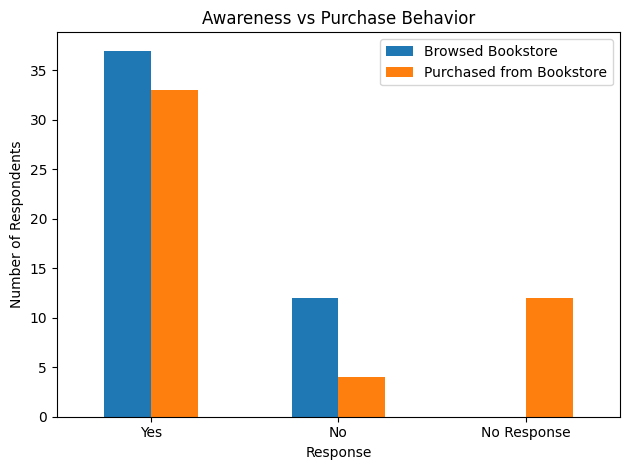

In [14]:
import matplotlib.pyplot as plt

q4_col = ("Q4", "Have you ever browsed the CWRU bookstore (in-person/online)?")
q6_col = ("Q6", "Have you ever purchased from the CWRU bookstore (in-person/online)?")

q4_counts = (
    survey_data[q4_col]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
    .reindex(["Yes", "No"], fill_value=0)
)

q6_counts = (
    survey_data[q6_col]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
    .reindex(["Yes", "No", "No Response"], fill_value=0)
)

awareness_purchase_df = pd.DataFrame({
    "Browsed Bookstore": [q4_counts["Yes"], q4_counts["No"], 0],
    "Purchased from Bookstore": [q6_counts["Yes"], q6_counts["No"], q6_counts["No Response"]]
}, index=["Yes", "No", "No Response"])

awareness_purchase_df.plot(kind="bar")
plt.title("Awareness vs Purchase Behavior")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

***Most Desired Apparel Types***

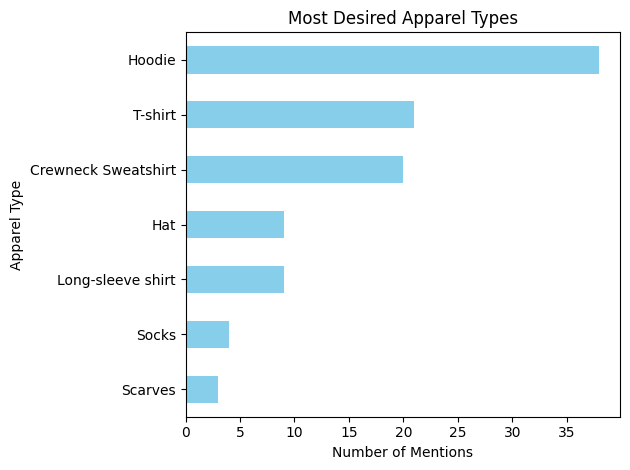

In [15]:
q7_col = ("Q7", "What type of clothing would you be most interested in purchasing?")

q7_counts = (
    survey_data[q7_col]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .sort_values(ascending=True)
)

q7_counts.plot(kind="barh", color='SkyBlue')
plt.title("Most Desired Apparel Types")
plt.xlabel("Number of Mentions")
plt.ylabel("Apparel Type")
plt.tight_layout()
plt.show()

***Most Important Factor When Buying Apparel***

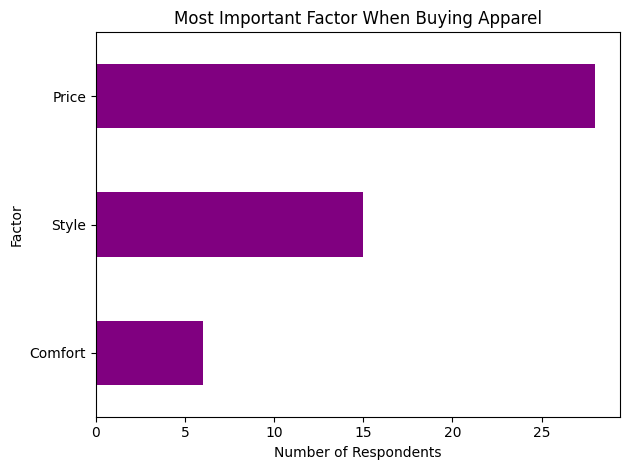

In [16]:
q8_col = ("Q8", "What is the most important factor you consider when deciding to purchase new apparel?")

q8_counts = (
    survey_data[q8_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .sort_values(ascending=True)
)

q8_counts.plot(kind="barh", color="purple")
plt.title("Most Important Factor When Buying Apparel")
plt.xlabel("Number of Respondents")
plt.ylabel("Factor")
plt.tight_layout()
plt.show()

***Promotion Types that Drive Engagement***

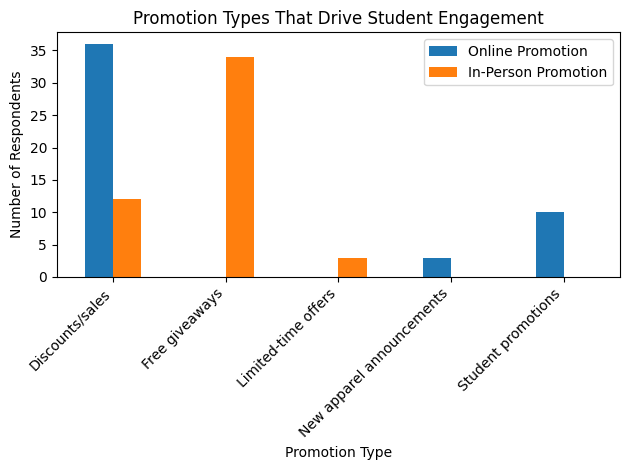

In [17]:
q17_col = ("Q17", "Which type of online advertisement would most influence you to purchase clothing?")
q22_col = ("Q22", "What would make you more likely to engage with an in-person promotion?")

q17_counts = (
    survey_data[q17_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

q22_counts = (
    survey_data[q22_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

promotion_categories = sorted(set(q17_counts.index).union(set(q22_counts.index)))

promotion_df = pd.DataFrame({
    "Online Promotion": q17_counts.reindex(promotion_categories, fill_value=0),
    "In-Person Promotion": q22_counts.reindex(promotion_categories, fill_value=0)
})

promotion_df.plot(kind="bar")
plt.title("Promotion Types That Drive Student Engagement")
plt.xlabel("Promotion Type")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

***Where Would you Prefer to Purchase CWRU Clothing***

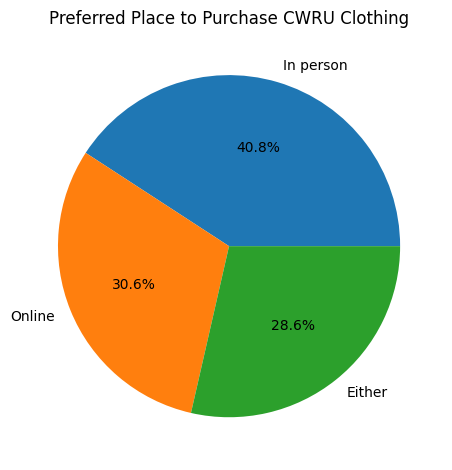

In [18]:
q13_col = ("Q13", "Where would you be most likely to purchase your CWRU apparel?")

q13_counts = (
    survey_data[q13_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)

q13_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Preferred Place to Purchase CWRU Clothing")
plt.ylabel("")
plt.tight_layout()
plt.show()

***Gender-Stratified EDA***

This visualization breaks down four key survey dimensions by gender to surface actionable differences that directly address the bookstore's Management Decision Problems. Each panel maps to a specific MDP: logo size preference (MDP 2 — subtle designs), purchase channel (MDP 3 — in-store vs. online), ad responsiveness (MDP 4 — advertising), and average spending (MDP 5 — pricing).

Respondents in plot: 19 Female, 28 Male


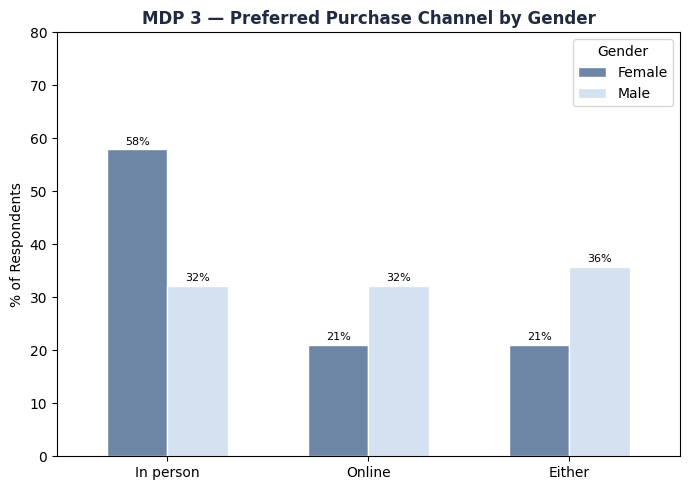

In [19]:
# ── Gender-Stratified EDA — MDP 3: Preferred Purchase Channel ────────────────

NAVY         = "#202a41"
FEMALE_COLOR = "#6e86a5"
MALE_COLOR   = "#d3e1f1"

q3_col  = ("Q3",  "What is your gender?")
q13_col = ("Q13", "Where would you be most likely to purchase your CWRU apparel?")

_cmap = {"in person": "In person", "online": "Online", "either": "Either"}

eda = pd.DataFrame({
    "gender":  survey_data[q3_col].str.strip(),
    "channel": survey_data[q13_col].str.strip().str.lower().map(_cmap),
})
eda = eda[eda["gender"].isin(["Female", "Male"])].dropna().reset_index(drop=True)

n_f = (eda["gender"] == "Female").sum()
n_m = (eda["gender"] == "Male").sum()
print(f"Respondents in plot: {n_f} Female, {n_m} Male")

chan_order = ["In person", "Online", "Either"]
cct = eda.groupby(["gender", "channel"]).size().reset_index(name="n")
cct["pct"] = cct["n"] / cct.groupby("gender")["n"].transform("sum") * 100
pivot_chan = cct.pivot(index="channel", columns="gender", values="pct").reindex(chan_order).fillna(0)

fig, ax = plt.subplots(figsize=(7, 5))
pivot_chan.plot(kind="bar", ax=ax, color=[FEMALE_COLOR, MALE_COLOR],
               edgecolor="white", width=0.6)
ax.set_title("MDP 3 — Preferred Purchase Channel by Gender", fontweight="bold", color=NAVY)
ax.set_xlabel("")
ax.set_ylabel("% of Respondents")
ax.set_xticklabels(chan_order, rotation=0)
ax.legend(title="Gender")
ax.set_ylim(0, 80)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", label_type="edge", fontsize=8, padding=2)

plt.tight_layout()
plt.show()